In [1]:
!pip install xgboost shap
!pip install --upgrade ipywidgets jupyter


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb
import shap

%matplotlib inline
sns.set_theme(style="whitegrid")

In [3]:
raw_data = load_breast_cancer()
data=pd.DataFrame(raw_data.data,columns=raw_data.feature_names)
data['target'] = raw_data.target
display(data.describe().T)
X = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
z = pd.Series(raw_data.target, name="target")

# Displaying EDA metrics
print("EDA")
print(f"Total number of samples (rows): {X.shape[0]}")
print(f"Total number of variables (columns): {X.shape[1]}")
print(f"Missing/null values in the dataset: {X.isnull().sum().sum()}")

print("\nClass distribution:")
counts = z.value_counts()
percentages = z.value_counts(normalize=True) * 100
for cls, name in zip([0, 1], raw_data.target_names):
    print(f" - Class {cls} ({name}): {counts[cls]} samples ({percentages[cls]:.2f}%)")

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


EDA
Total number of samples (rows): 569
Total number of variables (columns): 30
Missing/null values in the dataset: 0

Class distribution:
 - Class 0 (malignant): 212 samples (37.26%)
 - Class 1 (benign): 357 samples (62.74%)


In [4]:
#As we can see, class 0 is malignant, but that is not what we want, we need it to be the positive class for metrics like recall
y=1-z #invertimos valores
target_names=raw_data.target_names[::-1] #invertimos clases
print("\nNew class distribution:")
counts = y.value_counts()
percentages = y.value_counts(normalize=True) * 100
for cls, name in zip([0, 1], target_names):
    print(f" - Class {cls} ({name}): {counts[cls]} samples ({percentages[cls]:.2f}%)")

peso=round(10*counts[0]/counts[1],2)
print(peso)


New class distribution:
 - Class 0 (benign): 357 samples (62.74%)
 - Class 1 (malignant): 212 samples (37.26%)
16.84


In [5]:
#stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #train/test simple

print(f"Training samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

Training samples: 455 | Test samples: 114


In [6]:
# Training the XGBoost model with tuned parameters

model = xgb.XGBClassifier(
    n_estimators=500,
    scale_pos_weight=peso,
    learning_rate=0.01,
    min_child_weight=15,
    max_depth=3,
    random_state=42,
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

**Hyperparameter justification**
* We reduce the maximum depth to 3, forcing XGBoost to create simpler trees that only capture global interactions between cell geometries, drastically improving generalization on new data.
* Our dataset is small and with continuous features so correlated that such a high learning rate will make the algorithm converge abruptly and skip the optimal regularization point. By reducing the learning rate to a small value like 0.01, we manage to slow down the learning process, making the model add corrections smoothly. But in that case it will need more estimators, i.e., trees.
* Due to the two previous decisions, the model will need more trees to reach its maximum potential, so 100 will fall short. However, setting a high static number (like 500) on such a small dataset is dangerous. In this case, it would be advisable to apply cross-validation to control that it does not continue if it doesn't improve, but we stick to a basic train/test.
* We also limit the minimum sample number of each leaf to 15, to avoid overfitting by creating leaves for specific cases. This has been key to avoiding a precision of 1, which is a clear indicator of overfitting.
* We have also added a penalty for misclassifying the cancer class with scale_pos_weight=weight, with weight being the ratio of benign over malignant times ten.

**Relevant metrics**
In this critical case where the situation we want to avoid is false negatives, that is, diagnosing as benign when they are malignant. Therefore, the appropriate metric to maximize is Recall, since when FN is close to zero, recall is closer to 1. This metric is fundamental to evaluate the model because it is what we want beyond it predicting well both malignant and benign, an evaluation that Accuracy already does. That is, accuracy alone is not enough, we also need recall.

METRICS
Accuracy:  0.9737
Precision: 0.9535
Recall:    0.9762
F1-Score:  0.9647
AUC-ROC:   0.9960


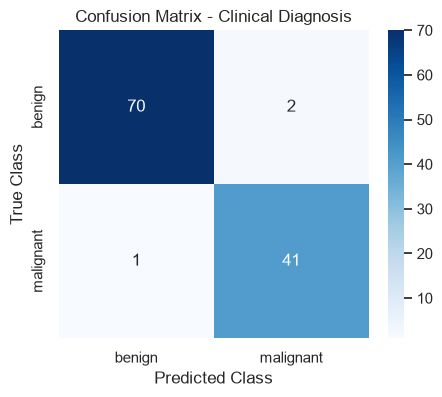

In [7]:
#calculation of required metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("METRICS")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {roc_auc:.4f}")

#CONFUSION MATRIX
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - Clinical Diagnosis")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

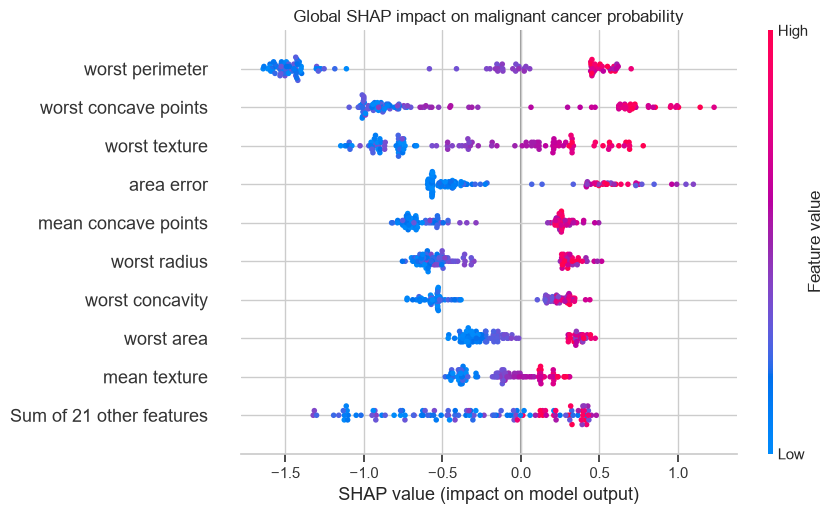

In [8]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

#with this we play it safe against the array list problem for any iteration we do
if isinstance(shap_values.values, list):
    shap_vals_plot = shap_values[1]
elif len(shap_values.values.shape) == 3:
    shap_vals_plot = shap_values.values[:, :, 1]
else:
    shap_vals_plot = shap_values.values
    
expl_bee = shap.Explanation(values=shap_vals_plot, 
                            base_values=explainer.expected_value,
                            data=X_test.values, 
                            feature_names=X_test.columns)

shap.plots.beeswarm(expl_bee, 
    max_display=10,
    show=False)
plt.title("Global SHAP impact on malignant cancer probability")
plt.show()

In [9]:
# Global importance: mean absolute SHAP value per variable
#we calculate the global importance as the mean of the absolute shap per variable
mean_abs_shap = np.abs(shap_vals_plot).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

top3 = shap_importance.head(3)
display(top3)

,feature,mean_abs_shap
22,worst perimeter,0.966400
27,worst concave points,0.804536
21,worst texture,0.561379


In the SHAP summary plot, the three variables with the greatest global impact on the probability of malignant breast cancer are:

1. `worst perimeter`: represents the maximum perimeter of the tumor observed in the sample. High values indicate larger tumors with more developed contours; in the plot, these high values systematically shift the SHAP values towards the positive side, increasing the probability of malignancy, which is consistent with clinical evidence that larger tumors are usually more aggressive.

2. `worst concave points`: measures the number and intensity of the most pronounced concavities in the tumor contour. A higher amount of concave points reflects irregular and invasive contours; in the plot, it is observed that high values of this variable are associated with positive SHAP contributions, pushing the prediction towards malignant.

3. `worst texture`: quantifies the maximum texture of the tissue, related to the variation of intensities in the image. More heterogeneous textures usually indicate disorganized cellular structures typical of malignant tumors; the model learns this relationship and, as the SHAP values show, high textures increase the estimated probability of malignancy.

High confidence correct case - dataset index: 250, test position: 1


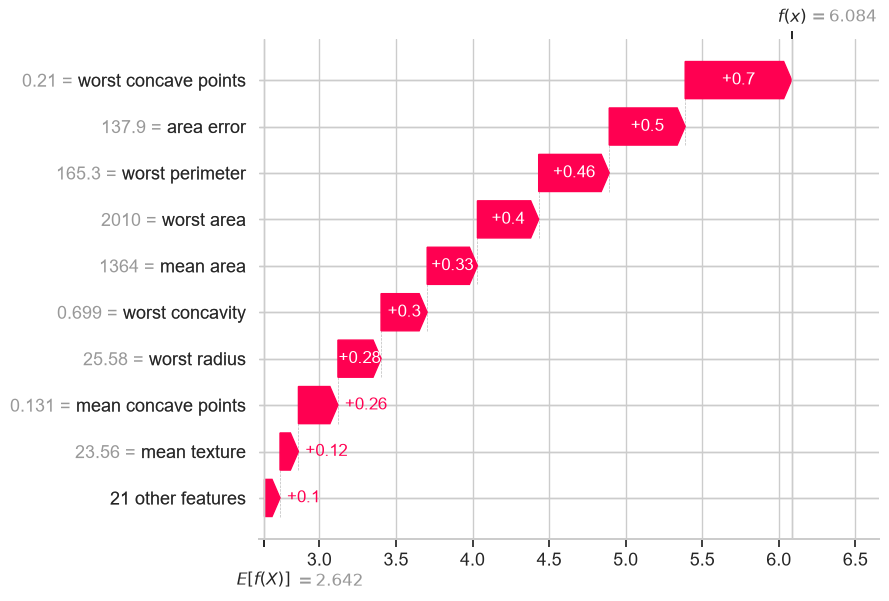

Erroneous or doubtful case - dataset index: 375, test position: 2


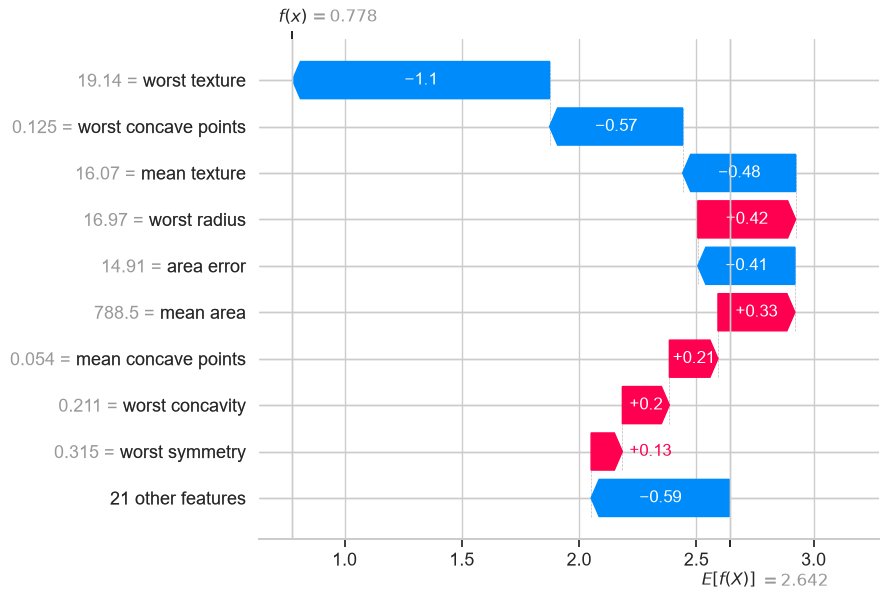

In [10]:
#predictions and probabilities on test
analisis_test = pd.DataFrame({
    "Actual": y_test,
    "Prediccion": y_pred,
    "Prob_maligno": y_prob
}, index=X_test.index)

# we select the correct malignant prediction case with high confidence
correctos_malignos = analisis_test[
    (analisis_test["Actual"] == 1) &
    (analisis_test["Prediccion"] == 1) &
    (analisis_test["Prob_maligno"] > 0.9)
]

if len(correctos_malignos) > 0:
    idx_correct = correctos_malignos.index[0]
    pos_correct = X_test.index.get_loc(idx_correct)
    print(f"High confidence correct case - dataset index: {idx_correct}, test position: {pos_correct}")

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_vals_plot[pos_correct],
            base_values=explainer.expected_value,
            data=X_test.iloc[pos_correct],
            feature_names=X_test.columns
        )
    )
else:
    print("No high confidence correct malignant case found in test.")

#we select the erroneous prediction case (FN or FP) or low confidence
errores_o_dudosos = analisis_test[
    (analisis_test["Actual"] != analisis_test["Prediccion"]) |
    ((analisis_test["Prob_maligno"] > 0.4) & (analisis_test["Prob_maligno"] < 0.6))
]

if len(errores_o_dudosos) > 0:
    idx_error = errores_o_dudosos.index[0]
    pos_error = X_test.index.get_loc(idx_error)
    print(f"Erroneous or doubtful case - dataset index: {idx_error}, test position: {pos_error}")

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_vals_plot[pos_error],
            base_values=explainer.expected_value,
            data=X_test.iloc[pos_error],
            feature_names=X_test.columns
        )
    )
else:
    print("No errors or low confidence predictions found in test.")

In the correct high-confidence case, variables like `worst perimeter`, `worst area`, and `worst concave points` clearly push the prediction towards malignant. The sum of their SHAP contributions moves the output away from the base value and justifies that the model is correct with certainty. In clinical terms, the sample presents features compatible with a large and irregular tumor.

On the other hand, in the incorrect or doubtful case, variables appear that push in opposite directions, so the final decision remains close to the threshold. Some features support malignancy, but others reduce that signal and generate uncertainty. This suggests a sample with an intermediate or less clear pattern for the model.

**What is the difference between the model's feature importance and the SHAP explanation? Which is more informative?**  
The model's feature importance summarizes which features contribute the most to reducing the error globally, but it does not explain individual predictions or the direction of the effect. SHAP decomposes each prediction into local contributions per variable, indicating how much and towards which class each feature moves the model's output. In this clinical context, SHAP is more informative because it allows justifying specific decisions for each patient and communicating to the medical team which features have led to considering a sample as high or low risk. This way we maintain a high degree of explainability, which is essential in critical environments like this.

**What ethical risk would deploying this model for automatic clinical decisions entail? How would you mitigate it?**  
The main ethical risk is delegating critical decisions to the model and having it commit false negatives, classifying truly malignant samples as benign and delaying diagnoses. In addition, the `load_breast_cancer` dataset may not represent the entire population, in fact it is very small, introducing biases. To mitigate these risks, the model should only be used as diagnostic support, with the final verdict always up to specialists, prior validation on real clinical data, and specific monitoring of serious errors (especially false negatives), along with human review protocols in the face of doubtful predictions. In addition, I would perform a finer training such as cross-validation that would allow imposing a specific evaluation metric improvement in each round.

**How would you detect that the model has stopped working in production 6 months later? Name a specific metric.**  
To detect degradation in production, I would continuously monitor the AUC-ROC metric on newly labeled cases, comparing it with the value obtained in testing. If the AUC-ROC clearly and steadily drops (for example, from approximately 0.996 to much lower values) or the false negative rate increases, we could interpret that there is drift or loss of performance and it would be necessary to activate a review procedure and possible retraining of the model with recent data. However, this has limits as it is necessary to have the data labels, that is, the clinical diagnosis, which can take time. In that case, we would use proxy metrics like the distribution of the predictions, so that an alteration in the distribution of the predicted classes can indicate to us that it is necessary to review and retrain.

**Which variable seems most influential? How would you communicate this result to a non-technical team?**  
In the global SHAP analysis, `worst perimeter` appears as the variable with the highest average impact on the probability of malignancy. I would explain that anomalously high values of this variable increase the probability of malignancy above the others: the larger and more developed the observed perimeter, the more likely the system considers the lesion to be cancerous, something that coincides with the clinical intuition that large tumors with extensive borders are usually more dangerous.

**NOTE**: Although the results of task 2 in part 2 are coherent, due to how the model has been trained and the metrics obtained such as a ROC-AUC of 0.996 and all others above 0.95, the model may have overfitting, especially the ROC-AUC being so high makes me doubt it. I have tried to shift the overfitting to maximize recall, for a methodological reason to show that it is the star metric of the model in this clinical context, at least among the primary metrics the most important and where we do not admit values worse than high.